# Desafio: Gastos de Campanha e Variáveis por Quartil

**Contexto:** Deputado Federal, UFs: DF, GO, MT, MS — Eleições 2026

Duas partes:
- **Parte 1:** Integrar `Total_Gasto_Campanha` ao `df_cluster` e avaliar se essa nova dimensão muda os clusters do K-Means.
- **Parte 2:** Criar versões categóricas (quartis) de todas as variáveis-driver para enriquecer a Fase 3 (Apriori).


## Configuração

In [1]:
CARGO = "DEPUTADO FEDERAL"   # mesmo valor usado nas Fases 0/1/2
UF = ['DF', 'GO', 'MT', 'MS']  # mesmo valor usado nas Fases 0/1/2
ANO_ELEICAO = 2026

## Imports e base de candidatos

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.optimize import linear_sum_assignment
from math import pi

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)

nome_uf = UF if isinstance(UF, str) else '_'.join(sorted(UF)) if UF else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')

# O arquivo gerado pela Fase 0 tem nome baseado na combinação de UFs usada
# Ajuste o nome abaixo conforme o arquivo gerado no seu 00_preparacao_dados.ipynb
# Ex.: 'dados/candidatos_DEPUTADO_FEDERAL_CENTRO_OESTE_2026.csv'
arquivo_candidatos = "dados/candidatos_DEPUTADO_FEDERAL_CENTRO_OESTE_2026.csv"

df = pd.read_csv(arquivo_candidatos)
print(f"Carregado: {arquivo_candidatos}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head(2)

Carregado: dados/candidatos_DEPUTADO_FEDERAL_CENTRO_OESTE_2026.csv  ->  692 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532001,3022,ALESSANDRA ALMEIDA CHIANELLI DUTRA,ALE CHIANELLI,#NULO,58442472134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,DF,1972-11-28,11236642070,4,FEMININO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,130000.0,0.0,0.0,0.0,0.0,130000.0,11.775297,53
1,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532002,3012,PAULO CESAR ECHEBARRIA DE CARVALHO,PAULO ECHEBARRIA,#NULO,37959077134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1965-10-20,7033782089,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,380000.0,0.0,0.0,0.0,15000000.0,15380000.0,16.548579,60


## Preparando a base — Versão 2 (mesma do 02_clusterizacao.ipynb)

Repetimos a preparação da Versão 2 para que este notebook rode de forma independente e os resultados sejam comparáveis com o K-Means já visto:
- Escolaridade convertida em anos de estudo equivalentes
- Outliers de patrimônio removidos por IQR (1,5×)
- 3 variáveis-driver padronizadas com `MinMaxScaler`

In [3]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — mesma decisão da Versão 2
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)
print("Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar):", df['ANOS_ESTUDO'].isna().sum())

Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar): 0


In [4]:
colunas_driver_orig = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']

Q1, Q3 = df['Total_Bens_Log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

antes = df.shape[0]
df_cluster = df[(df['Total_Bens_Log'] <= limite_superior) & (df['ANOS_ESTUDO'].notna())].copy()
print(f"Removidos {antes - df_cluster.shape[0]} candidatos "
      f"(patrimônio extremo acima de ~R$ {np.expm1(limite_superior):,.0f}, ou escolaridade não divulgada)")
print(f"Base para clusterização: {df_cluster.shape[0]} candidatos")

colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']
colunas_perfil = [c for c in colunas_perfil if c in df_cluster.columns]

df_cluster[colunas_driver_orig].describe()

Removidos 0 candidatos (patrimônio extremo acima de ~R$ 927,725,026,861,692, ou escolaridade não divulgada)
Base para clusterização: 692 candidatos


,IDADE,ANOS_ESTUDO,Total_Bens_Log
count,692.000000,692.000000,692.000000
mean,48.566474,14.114162,9.405752
std,12.508980,3.007944,6.094687
min,21.000000,1.000000,0.000000
25%,40.000000,13.000000,0.000000
50%,48.000000,16.000000,12.248638
75%,57.000000,16.000000,13.785503
max,86.000000,16.000000,18.457336


## 1.1) Lendo e explorando os dados de despesas contratadas

O arquivo `despesas_contratadas_candidatos_2026_{UF}.csv` contém uma linha por despesa contratada — ou seja, compromissos assumidos pela campanha, independentemente de já ter sido pago. Optamos por usar **despesas contratadas** (em vez de pagas) porque representa o total de investimento comprometido pela campanha até o momento da coleta, que é o retrato mais fiel do "quanto a campanha está investindo".

**Decisão:** `VR_DESPESA_CONTRATADA` como proxy de gasto de campanha, somado por `SQ_CANDIDATO`.

**Arquivos utilizados** (todos em `dados/`):
- `despesas_contratadas_candidatos_2026_DF.csv` — extraído do arquivo BRASIL (DF não tem arquivo próprio no zip do TSE)
- `despesas_contratadas_candidatos_2026_GO.csv`
- `despesas_contratadas_candidatos_2026_MT.csv`
- `despesas_contratadas_candidatos_2026_MS.csv`


In [5]:
# CSVs de despesas contratadas — um arquivo por UF, todos em dados/
# (DF foi extraído do arquivo BRASIL pelo script de preparação)

COLS_DESPESA = ['SG_UF', 'DS_CARGO', 'SQ_CANDIDATO', 'VR_DESPESA_CONTRATADA']

chunks = []
for uf in ['DF', 'GO', 'MT', 'MS']:
    caminho = f"dados/despesas_contratadas_candidatos_2026_{uf}.csv"
    df_uf = pd.read_csv(caminho, sep=';', encoding='latin-1', usecols=COLS_DESPESA)
    df_uf = df_uf[df_uf['DS_CARGO'].str.upper() == 'DEPUTADO FEDERAL']
    chunks.append(df_uf)
    print(f"  {uf}: {len(df_uf):,} linhas de Deputado Federal")

df_despesas = pd.concat(chunks, ignore_index=True)
print(f"\nTotal de linhas de despesas (Deputado Federal, DF+GO+MT+MS): {len(df_despesas):,}")
df_despesas.head(3)

  DF: 10,428 linhas de Deputado Federal
  GO: 16,349 linhas de Deputado Federal
  MT: 8,970 linhas de Deputado Federal
  MS: 9,552 linhas de Deputado Federal

Total de linhas de despesas (Deputado Federal, DF+GO+MT+MS): 45,299


,SG_UF,DS_CARGO,SQ_CANDIDATO,VR_DESPESA_CONTRATADA
0,DF,Deputado Federal,70002537007,"4100,00"
1,DF,Deputado Federal,70002538935,"36,95"
2,DF,Deputado Federal,70002538935,"23,40"


## 1.2) Convertendo valores e agregando por candidato

In [6]:
# VR_DESPESA_CONTRATADA usa vírgula como separador decimal (padrão TSE)
df_despesas['VR_DESPESA_CONTRATADA'] = (
    df_despesas['VR_DESPESA_CONTRATADA']
    .astype(str)
    .str.replace('.', '', regex=False)   # remove separador de milhar (ponto)
    .str.replace(',', '.', regex=False)  # troca decimal vírgula -> ponto
    .pipe(pd.to_numeric, errors='coerce')
)

# Soma por candidato (pivot_table com aggfunc='sum', mesma lógica do Total_Bens)
gasto_por_candidato = (
    df_despesas.groupby('SQ_CANDIDATO', as_index=False)['VR_DESPESA_CONTRATADA']
    .sum()
    .rename(columns={'VR_DESPESA_CONTRATADA': 'Total_Gasto_Campanha'})
)

print(f"Candidatos com pelo menos 1 despesa registrada: {len(gasto_por_candidato):,}")
print(f"Candidatos na base de clusterização: {df_cluster.shape[0]:,}")
print(f"\nEstatísticas de Total_Gasto_Campanha:")
print(gasto_por_candidato['Total_Gasto_Campanha'].describe().apply(lambda x: f'R$ {x:,.2f}'))

Candidatos com pelo menos 1 despesa registrada: 666
Candidatos na base de clusterização: 692

Estatísticas de Total_Gasto_Campanha:
count          R$ 666.00
mean       R$ 246,769.49
std        R$ 459,088.88
min              R$ 0.00
25%          R$ 2,337.75
50%         R$ 40,002.50
75%        R$ 243,712.60
max      R$ 2,887,585.51
Name: Total_Gasto_Campanha, dtype: str


## 1.3) Juntando ao df_cluster e tratando zeros

**Decisão de tratamento:** candidatos sem nenhuma despesa registrada no arquivo do TSE não aparecem no join — o `NaN` resultante representa **zero gasto**, não "não sabemos". Portanto, aplicamos `fillna(0)` antes de logaritmizar.

Isso é diferente do tratamento de `Total_Bens` (onde `NaN` genuíno significa informação ausente): aqui o sistema IDC registra todas as despesas declaradas; ausência de registro = nenhuma despesa declarada até agora.

In [7]:
df_cluster = df_cluster.merge(
    gasto_por_candidato[['SQ_CANDIDATO', 'Total_Gasto_Campanha']],
    on='SQ_CANDIDATO',
    how='left'
)

# Candidatos sem nenhum registro = zero gasto (não informação ausente — ver nota acima)
n_sem_registro_despesa = df_cluster['Total_Gasto_Campanha'].isna().sum()
df_cluster['Total_Gasto_Campanha'] = df_cluster['Total_Gasto_Campanha'].fillna(0)
n_gasto_zero = df_cluster['Total_Gasto_Campanha'].eq(0).sum()

# Log1p pela mesma razão do patrimônio: distribuição super assimétrica
df_cluster['Total_Gasto_Campanha_Log'] = np.log1p(df_cluster['Total_Gasto_Campanha'])

print(f"Candidatos sem registro de despesa (preenchidos com zero): {n_sem_registro_despesa} "
      f"({n_sem_registro_despesa/df_cluster.shape[0]:.1%} da base)")
print(f"Candidatos com gasto total igual a zero: {n_gasto_zero} "
      f"({n_gasto_zero/df_cluster.shape[0]:.1%} da base)")
print(f"\nEstatísticas após join (Total_Gasto_Campanha):")
df_cluster[['Total_Gasto_Campanha', 'Total_Gasto_Campanha_Log']].describe().round(2)

Candidatos sem registro de despesa (preenchidos com zero): 30 (4.3% da base)
Candidatos com gasto total igual a zero: 156 (22.5% da base)

Estatísticas após join (Total_Gasto_Campanha):


,Total_Gasto_Campanha,Total_Gasto_Campanha_Log
count,692.00,692.00
mean,237302.74,8.58
std,452885.04,5.03
min,0.00,0.00
25%,1000.75,6.91
50%,35765.28,10.48
75%,220078.96,12.30
max,2887585.51,14.88


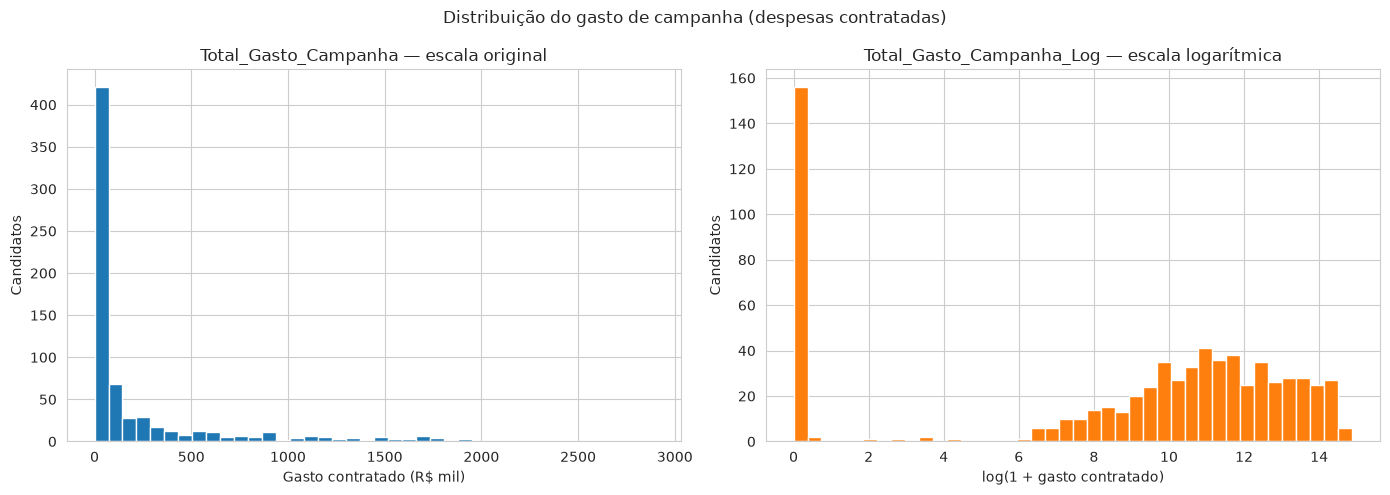


Correlação entre Total_Bens_Log e Total_Gasto_Campanha_Log: 0.417


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_cluster['Total_Gasto_Campanha'] / 1e3, bins=40, color='tab:blue', edgecolor='white')
axes[0].set_xlabel('Gasto contratado (R$ mil)')
axes[0].set_ylabel('Candidatos')
axes[0].set_title('Total_Gasto_Campanha — escala original')

axes[1].hist(df_cluster['Total_Gasto_Campanha_Log'], bins=40, color='tab:orange', edgecolor='white')
axes[1].set_xlabel('log(1 + gasto contratado)')
axes[1].set_ylabel('Candidatos')
axes[1].set_title('Total_Gasto_Campanha_Log — escala logarítmica')

plt.suptitle('Distribuição do gasto de campanha (despesas contratadas)')
plt.tight_layout()
plt.show()

# Correlação com Total_Bens_Log
corr = df_cluster[['Total_Bens_Log', 'Total_Gasto_Campanha_Log']].corr()
print(f"\nCorrelação entre Total_Bens_Log e Total_Gasto_Campanha_Log: "
      f"{corr.loc['Total_Bens_Log','Total_Gasto_Campanha_Log']:.3f}")

## 1.4) K-Means com 3 variáveis (baseline) vs. 4 variáveis (com gasto)

Rodamos o K-Means com **k=6** (mesmo k definido na Fase 2) em dois cenários:
- **Baseline:** as 3 variáveis-driver originais (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`)
- **Novo:** 4 variáveis, acrescentando `Total_Gasto_Campanha_Log`

Comparamos silhouette, composição dos clusters e radar.

In [9]:
k_final = 6  # mesmo k definido no 02_clusterizacao.ipynb (Versão 2)

colunas_driver_3v = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']
colunas_driver_4v = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Gasto_Campanha_Log']

scaler_3v = MinMaxScaler()
X_3v = scaler_3v.fit_transform(df_cluster[colunas_driver_3v])

scaler_4v = MinMaxScaler()
X_4v = scaler_4v.fit_transform(df_cluster[colunas_driver_4v])

# K-Means — 3 variáveis (baseline)
km_3v = KMeans(n_clusters=k_final, random_state=SEMENTE, n_init=10)
df_cluster['cluster_3v'] = km_3v.fit_predict(X_3v)
df_cluster['cluster_3v'] = df_cluster['cluster_3v'].map(lambda x: chr(65 + x))
sil_3v = silhouette_score(X_3v, df_cluster['cluster_3v'])

# K-Means — 4 variáveis (com gasto)
km_4v = KMeans(n_clusters=k_final, random_state=SEMENTE, n_init=10)
df_cluster['cluster_4v'] = km_4v.fit_predict(X_4v)
df_cluster['cluster_4v'] = df_cluster['cluster_4v'].map(lambda x: chr(65 + x))
sil_4v = silhouette_score(X_4v, df_cluster['cluster_4v'])

print(f"K-Means 3v (baseline)  — silhouette: {sil_3v:.3f}")
print(f"K-Means 4v (com gasto) — silhouette: {sil_4v:.3f}")
print(f"\nDistribuição 3v:", dict(df_cluster['cluster_3v'].value_counts().sort_index()))
print(f"Distribuição 4v:", dict(df_cluster['cluster_4v'].value_counts().sort_index()))

K-Means 3v (baseline)  — silhouette: 0.404
K-Means 4v (com gasto) — silhouette: 0.366

Distribuição 3v: {'A': np.int64(223), 'B': np.int64(45), 'C': np.int64(91), 'D': np.int64(65), 'E': np.int64(182), 'F': np.int64(86)}
Distribuição 4v: {'A': np.int64(196), 'B': np.int64(86), 'C': np.int64(154), 'D': np.int64(69), 'E': np.int64(77), 'F': np.int64(110)}


## 1.5) Radar comparativo: 3v vs. 4v

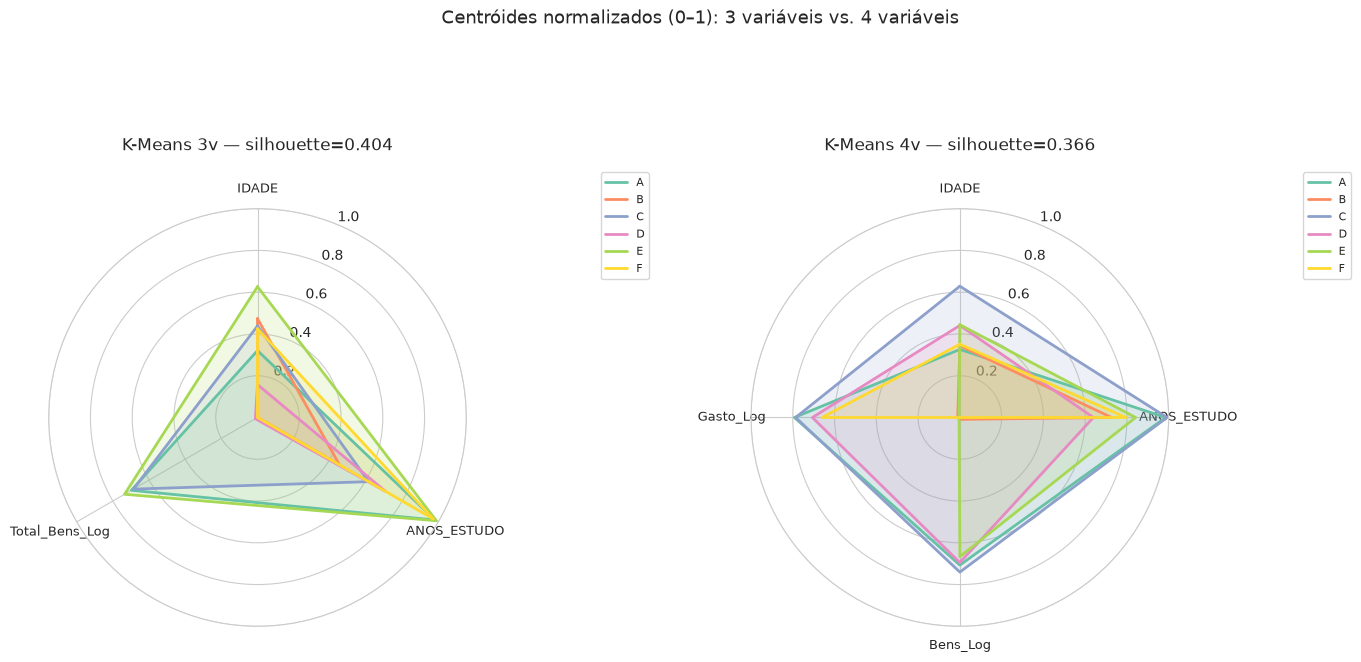

In [10]:
def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)
    angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos, size=9)
    ax.set_ylim(0, 1)

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[i] if isinstance(cores, list) else cores[labels_series[i]]
        ax.plot(angulos, valores, linewidth=2, label=labels_series[i], color=cor)
        ax.fill(angulos, valores, alpha=0.15, color=cor)

    ax.set_title(titulo, y=1.12)
    ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=8)


palette = sns.color_palette('Set2', n_colors=k_final)
cores_clusters = {chr(65 + i): palette[i] for i in range(k_final)}

centroides_3v = np.array([
    X_3v[df_cluster['cluster_3v'].values == cl].mean(axis=0)
    for cl in sorted(df_cluster['cluster_3v'].unique())
])

centroides_4v = np.array([
    X_4v[df_cluster['cluster_4v'].values == cl].mean(axis=0)
    for cl in sorted(df_cluster['cluster_4v'].unique())
])

fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw=dict(polar=True))

labels_3v = sorted(df_cluster['cluster_3v'].unique())
plot_radar(axes[0], centroides_3v, colunas_driver_3v, labels_3v, palette, f'K-Means 3v — silhouette={sil_3v:.3f}')

labels_4v = sorted(df_cluster['cluster_4v'].unique())
# Abreviar os labels dos eixos para caber no gráfico
labels_eixos_4v = ['IDADE', 'ANOS_ESTUDO', 'Bens_Log', 'Gasto_Log']
plot_radar(axes[1], centroides_4v, labels_eixos_4v, labels_4v, palette, f'K-Means 4v — silhouette={sil_4v:.3f}')

plt.suptitle('Centróides normalizados (0–1): 3 variáveis vs. 4 variáveis', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 1.6) Tabela de contingência: os clusters mudaram?

In [11]:
print("Tabela de contingência — cluster_3v x cluster_4v:")
contingencia = pd.crosstab(df_cluster['cluster_3v'], df_cluster['cluster_4v'])
display(contingencia)

# As letras são arbitrárias entre os modelos. Alinhamos os rótulos pela combinação
# que maximiza a correspondência antes de contar permanências e mudanças.
linhas_match, colunas_match = linear_sum_assignment(-contingencia.to_numpy())
n_equivalentes = contingencia.to_numpy()[linhas_match, colunas_match].sum()
n_reorganizados = len(df_cluster) - n_equivalentes
print(
    f'Após alinhar os rótulos: {n_equivalentes} candidatos ({n_equivalentes/len(df_cluster):.1%}) '
    f'permanecem em grupos equivalentes e {n_reorganizados} ({n_reorganizados/len(df_cluster):.1%}) mudam de grupo.'
)

print("\nFicha técnica — K-Means 4v (com gasto de campanha):")
ficha_4v = df_cluster.groupby('cluster_4v').agg(
    qtd=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
    gasto_mediano=('Total_Gasto_Campanha', 'median'),
    gasto_medio=('Total_Gasto_Campanha', 'mean'),
    pct_zero_gasto=('Total_Gasto_Campanha', lambda x: (x == 0).mean() * 100),
).round(1)
ficha_4v['gasto_mediano'] = ficha_4v['gasto_mediano'].apply(lambda x: f'R$ {x:,.0f}')
ficha_4v['gasto_medio'] = ficha_4v['gasto_medio'].apply(lambda x: f'R$ {x:,.0f}')
ficha_4v['patrimonio_mediano'] = ficha_4v['patrimonio_mediano'].apply(lambda x: f'R$ {x:,.0f}')
display(ficha_4v)

Tabela de contingência — cluster_3v x cluster_4v:


cluster_4v,A,B,C,D,E,F
cluster_3v,,,,,,
A,192,0,0,3,28,0
B,0,23,0,0,0,22
C,1,0,0,64,26,0
D,0,31,0,0,0,34
E,3,0,154,2,23,0
F,0,32,0,0,0,54


Após alinhar os rótulos: 495 candidatos (71.5%) permanecem em grupos equivalentes e 197 (28.5%) mudam de grupo.

Ficha técnica — K-Means 4v (com gasto de campanha):


,qtd,idade_media,anos_estudo_medio,patrimonio_mediano,gasto_mediano,gasto_medio,pct_zero_gasto
cluster_4v,,,,,,,
A,196,42.2,15.8,"R$ 544,710","R$ 178,861","R$ 404,176",0.0
B,86,43.3,11.9,R$ 0,R$ 0,R$ 2,94.2
C,154,61.9,15.9,"R$ 975,736","R$ 137,761","R$ 435,174",0.0
D,69,49.7,10.6,"R$ 395,000","R$ 46,738","R$ 187,647",0.0
E,77,49.9,13.6,"R$ 250,000",R$ 0,R$ 0,97.4
F,110,43.8,12.9,R$ 0,"R$ 20,750","R$ 45,731",0.0


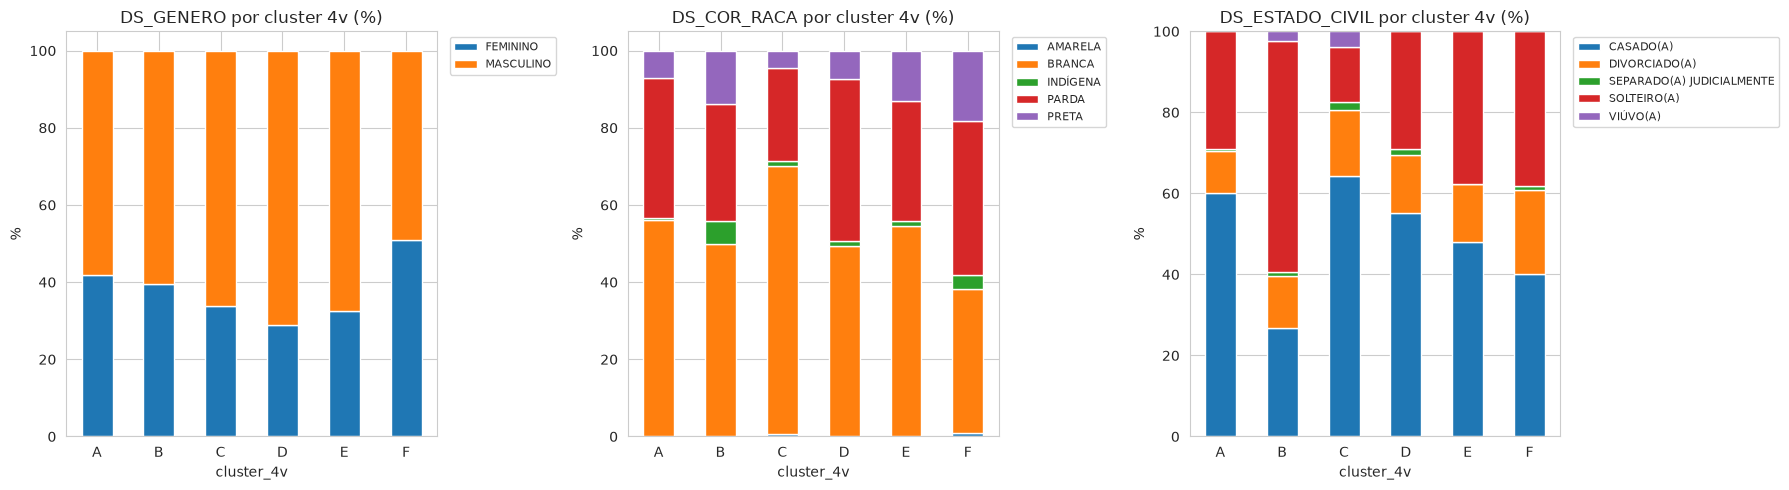

In [12]:
# Perfil demográfico dos clusters 4v
fig, axes = plt.subplots(1, len(colunas_perfil), figsize=(6 * len(colunas_perfil), 5))
if len(colunas_perfil) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas_perfil):
    pd.crosstab(df_cluster['cluster_4v'], df_cluster[col], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=ax
    )
    ax.set_title(f'{col} por cluster 4v (%)')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 1.7) Gasto vs. Patrimônio: são dimensões diferentes?

Scatter para ver visualmente se quem gasta mais é o mesmo grupo dos "Abastados" (alto patrimônio) ou se gasto de campanha é uma dimensão independente.

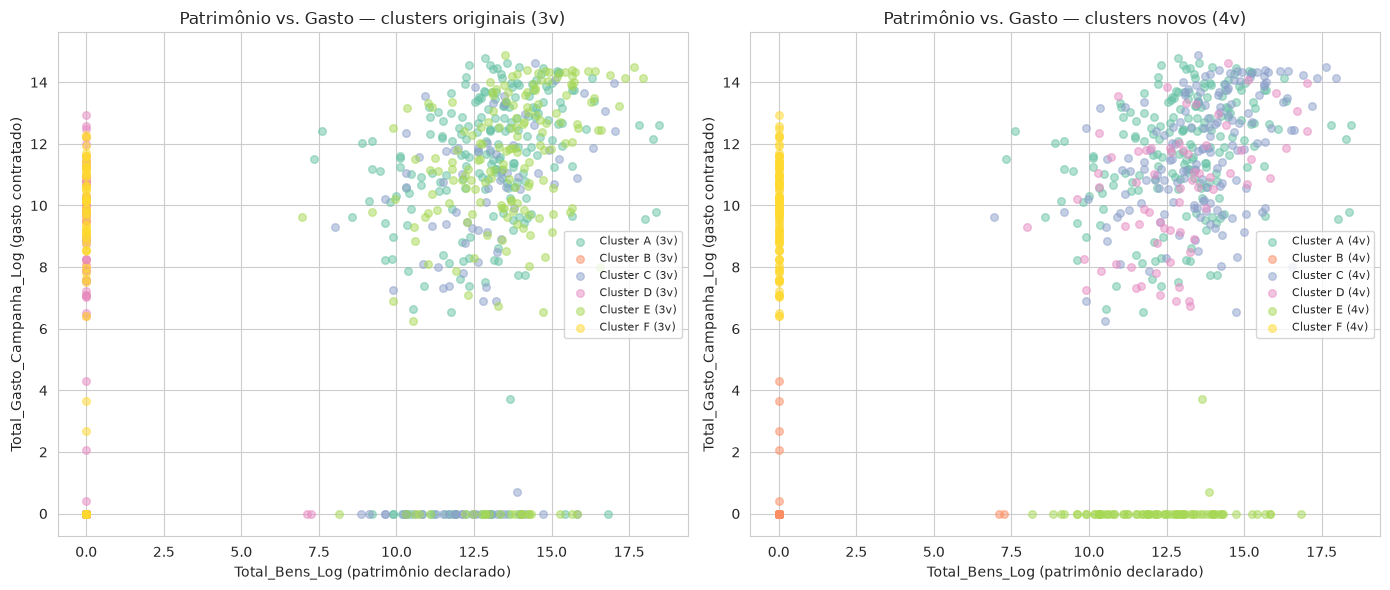

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: patrimônio x gasto (escala log), colorido pelo cluster 3v
for cl in sorted(df_cluster['cluster_3v'].unique()):
    subset = df_cluster[df_cluster['cluster_3v'] == cl]
    axes[0].scatter(
        subset['Total_Bens_Log'], subset['Total_Gasto_Campanha_Log'],
        label=f'Cluster {cl} (3v)', alpha=0.5, s=30, color=cores_clusters[cl]
    )
axes[0].set_xlabel('Total_Bens_Log (patrimônio declarado)')
axes[0].set_ylabel('Total_Gasto_Campanha_Log (gasto contratado)')
axes[0].set_title('Patrimônio vs. Gasto — clusters originais (3v)')
axes[0].legend(fontsize=8)

# Scatter: patrimônio x gasto, colorido pelo cluster 4v
for cl in sorted(df_cluster['cluster_4v'].unique()):
    subset = df_cluster[df_cluster['cluster_4v'] == cl]
    axes[1].scatter(
        subset['Total_Bens_Log'], subset['Total_Gasto_Campanha_Log'],
        label=f'Cluster {cl} (4v)', alpha=0.5, s=30, color=cores_clusters[cl]
    )
axes[1].set_xlabel('Total_Bens_Log (patrimônio declarado)')
axes[1].set_ylabel('Total_Gasto_Campanha_Log (gasto contratado)')
axes[1].set_title('Patrimônio vs. Gasto — clusters novos (4v)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Resposta à pergunta de verdade

> **Incluir `Total_Gasto_Campanha_Log` como 4ª variável-driver muda os clusters?**

Com `k=6`, o gasto de campanha **altera parcialmente a composição dos grupos**, mas não melhora sua separação. Após alinhar os rótulos dos dois modelos pela maior correspondência possível, 495 dos 692 candidatos (71,5%) permanecem em grupos equivalentes e 197 (28,5%) mudam de grupo. A correlação entre patrimônio e gasto em escala logarítmica é moderada (`0,417`), portanto as variáveis não representam exatamente a mesma dimensão.

Apesar dessa informação adicional, a silhouette cai de `0,404` no modelo com três variáveis para `0,366` no modelo com quatro. Assim, o gasto reorganiza parte dos candidatos, porém reduz a separação dos clusters. **Mantemos como modelo oficial as três variáveis definidas na Fase 2: idade, tempo de estudo e total de bens declarados.** O total de despesas declaradas permanece como variável descritiva complementar e como faixa categórica para as regras de associação.

---
# Parte 2 — Variáveis categóricas por quartil

Para cada variável numérica usada como driver na clusterização, criamos uma versão categórica em 4 faixas (quartis). Isso permite que o Apriori (Fase 3) use essas variáveis como itens de cesta.

- `Q1` = 25% mais baixo, `Q4` = 25% mais alto
- `duplicates='drop'` evita erro quando há valores repetidos — verificamos quantas faixas saíram de fato.

**Atenção ao `Total_Bens_Log`:** há muitos candidatos com patrimônio zero declarado, o que pode colapsar Q1 e Q2 num mesmo valor de corte — `duplicates='drop'` pode resultar em menos de 4 faixas.

In [14]:
# Variáveis para discretizar — inclui Total_Gasto_Campanha_Log se você decidir usá-la na Parte 1
vars_para_discretizar = {
    'IDADE': 'IDADE_Faixa',
    'ANOS_ESTUDO': 'ANOS_ESTUDO_Faixa',
    'Total_Bens_Log': 'Total_Bens_Log_Faixa',
    'Total_Gasto_Campanha_Log': 'Total_Gasto_Campanha_Log_Faixa',
}

for var_orig, var_faixa in vars_para_discretizar.items():
    # pd.qcut com duplicates='drop' pode gerar MENOS de 4 bins se há muitos valores repetidos
    # (ex.: ANOS_ESTUDO tem poucos valores únicos; Total_Bens_Log tem muitos zeros).
    # Calculamos quantos bins reais sobram e ajustamos os labels dinamicamente para evitar ValueError.
    _, bins_tmp = pd.qcut(df_cluster[var_orig], q=4, duplicates='drop', retbins=True)
    n_bins_reais = len(bins_tmp) - 1
    labels_dyn = ['Q1', 'Q2', 'Q3', 'Q4'][:n_bins_reais]
    df_cluster[var_faixa] = pd.qcut(
        df_cluster[var_orig], q=4, labels=labels_dyn, duplicates='drop'
    )
    n_faixas = df_cluster[var_faixa].nunique()
    contagem = df_cluster[var_faixa].value_counts().sort_index()

    print(f"\n{var_orig} → {var_faixa} ({n_faixas} faixas):")
    if n_faixas < 4:
        print(f"  ⚠️  Apenas {n_faixas} faixas (esperadas 4) — duplicates='drop' colapsou categorias.")
        print(f"     Motivo provável: muitos valores repetidos (ex.: zeros em {var_orig}).")
    print(contagem.to_string())


IDADE → IDADE_Faixa (4 faixas):
IDADE_Faixa
Q1    181
Q2    177
Q3    163
Q4    171

ANOS_ESTUDO → ANOS_ESTUDO_Faixa (2 faixas):
  ⚠️  Apenas 2 faixas (esperadas 4) — duplicates='drop' colapsou categorias.
     Motivo provável: muitos valores repetidos (ex.: zeros em ANOS_ESTUDO).
ANOS_ESTUDO_Faixa
Q1    241
Q2    451

Total_Bens_Log → Total_Bens_Log_Faixa (3 faixas):
  ⚠️  Apenas 3 faixas (esperadas 4) — duplicates='drop' colapsou categorias.
     Motivo provável: muitos valores repetidos (ex.: zeros em Total_Bens_Log).
Total_Bens_Log_Faixa
Q1    346
Q2    173
Q3    173

Total_Gasto_Campanha_Log → Total_Gasto_Campanha_Log_Faixa (4 faixas):
Total_Gasto_Campanha_Log_Faixa
Q1    173
Q2    173
Q3    173
Q4    173


## 2.1) Visualizando as faixas

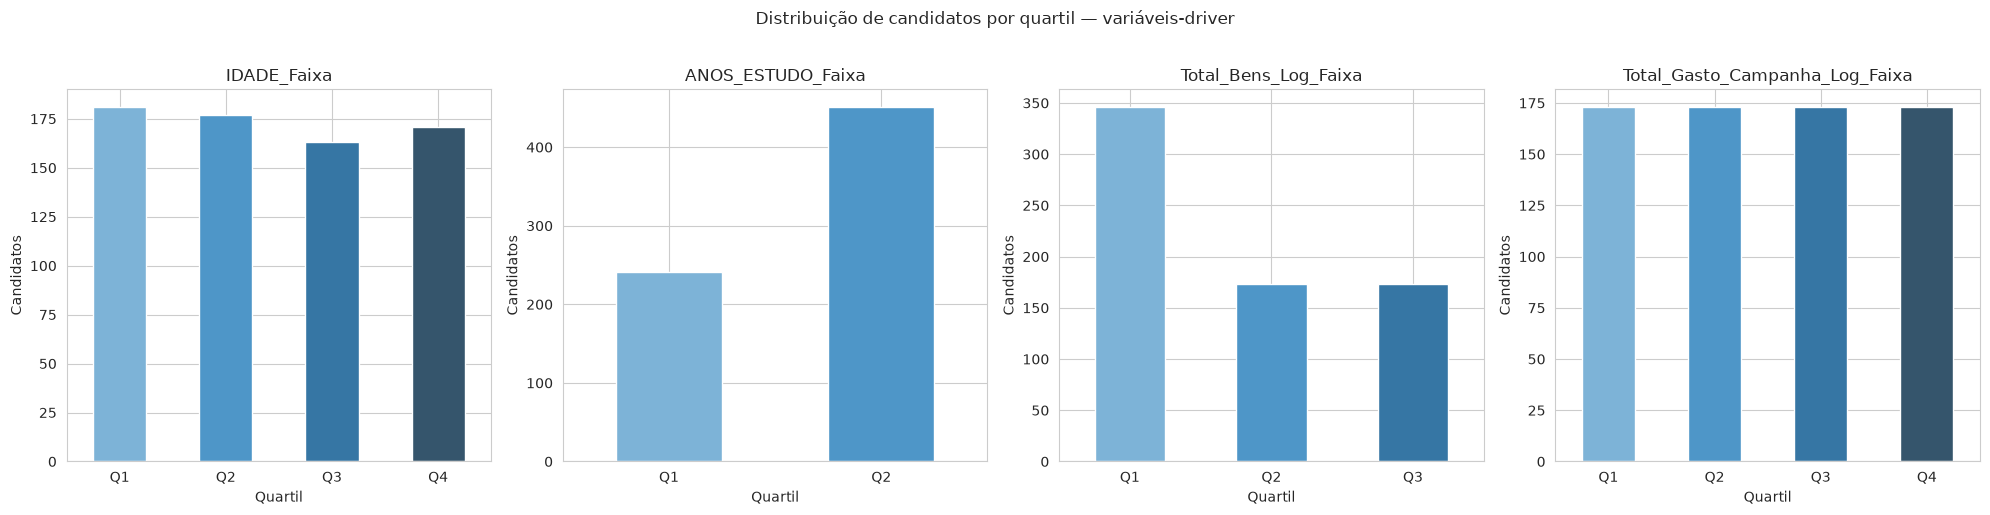

In [15]:
n_vars = len(vars_para_discretizar)
fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 5))
if n_vars == 1:
    axes = [axes]

for ax, (var_orig, var_faixa) in zip(axes, vars_para_discretizar.items()):
    df_cluster[var_faixa].value_counts().sort_index().plot(
        kind='bar', ax=ax, color=sns.color_palette('Blues_d', n_colors=4), edgecolor='white'
    )
    ax.set_title(var_faixa)
    ax.set_xlabel('Quartil')
    ax.set_ylabel('Candidatos')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribuição de candidatos por quartil — variáveis-driver', y=1.02)
plt.tight_layout()
plt.show()

## 2.2) Verificando as faixas junto ao cluster (para orientar o Apriori)

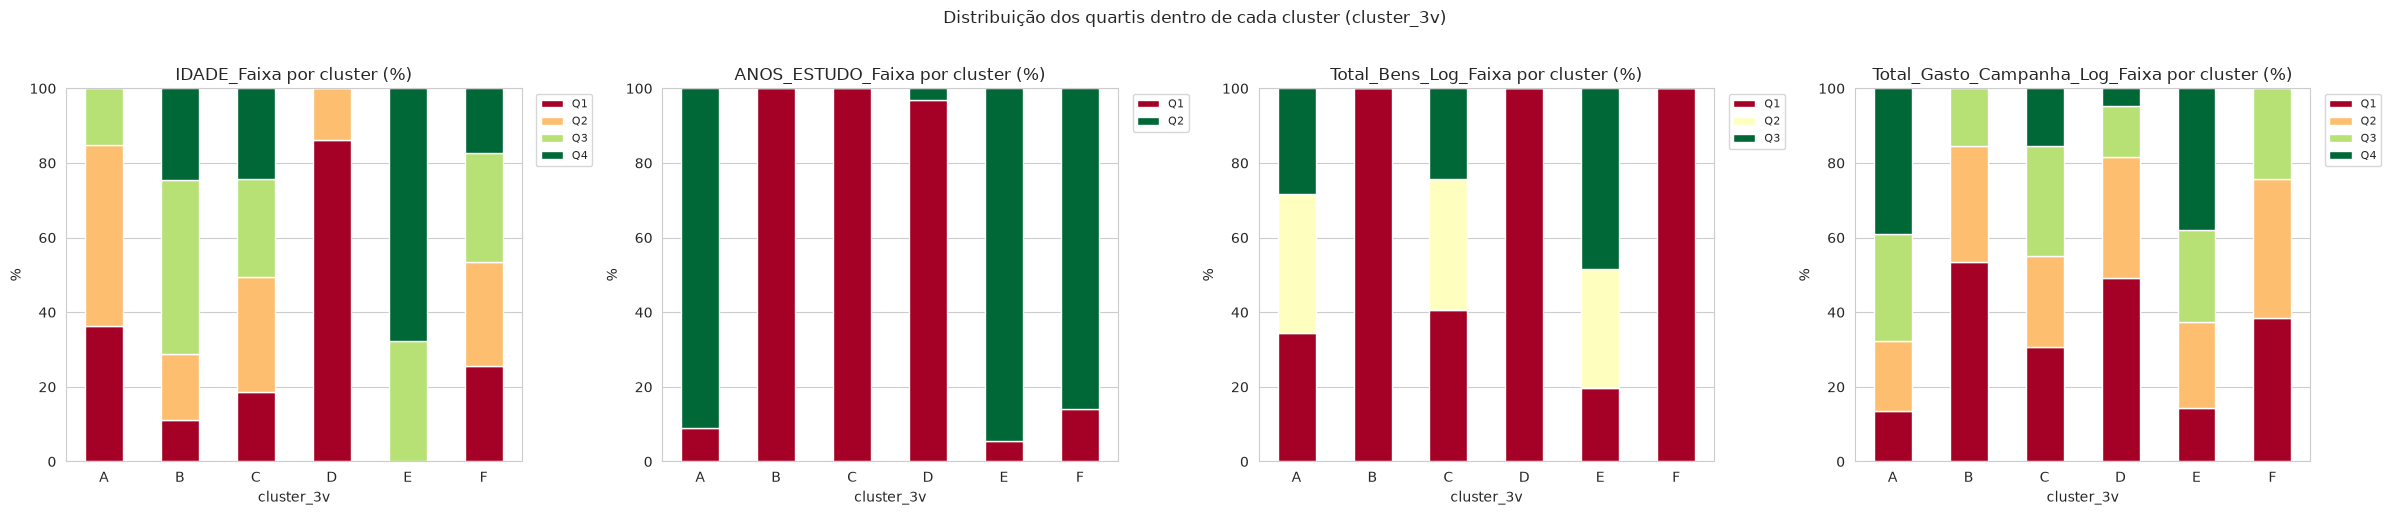

In [16]:
# Usando o cluster do modelo de 3 variáveis como referência (mesmo da Fase 2)
# (troque para 'cluster_4v' se decidir adotar o modelo com gasto)
cluster_referencia = 'cluster_3v'

fig, axes = plt.subplots(1, n_vars, figsize=(6 * n_vars, 5))
if n_vars == 1:
    axes = [axes]

for ax, (var_orig, var_faixa) in zip(axes, vars_para_discretizar.items()):
    tabela = pd.crosstab(df_cluster[cluster_referencia], df_cluster[var_faixa], normalize='index').mul(100)
    tabela.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn')
    ax.set_title(f'{var_faixa} por cluster (%)')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.suptitle(f'Distribuição dos quartis dentro de cada cluster ({cluster_referencia})', y=1.02)
plt.tight_layout()
plt.show()

## 2.3) Salvando df_cluster atualizado

Para que o `03_regras_associacao.ipynb` possa reaproveitar as colunas `_Faixa` e `Total_Gasto_Campanha_Log`, salvamos o `df_cluster` enriquecido.

In [17]:
arquivo_saida = f"dados/candidatos_{nome_cargo}_COM_GASTO_FAIXAS_{ANO_ELEICAO}.csv"
df_cluster.to_csv(arquivo_saida, index=False)

print(f"Salvo: {arquivo_saida}")
print(f"Shape: {df_cluster.shape}")
print("\nColunas novas adicionadas:")
novas_colunas = ['Total_Gasto_Campanha', 'Total_Gasto_Campanha_Log',
                 'cluster_3v', 'cluster_4v'] + list(vars_para_discretizar.values())
for c in novas_colunas:
    if c in df_cluster.columns:
        print(f"  ✓ {c}")
df_cluster.head(2)

Salvo: dados/candidatos_DEPUTADO_FEDERAL_COM_GASTO_FAIXAS_2026.csv
Shape: (692, 68)

Colunas novas adicionadas:
  ✓ Total_Gasto_Campanha
  ✓ Total_Gasto_Campanha_Log
  ✓ cluster_3v
  ✓ cluster_4v
  ✓ IDADE_Faixa
  ✓ ANOS_ESTUDO_Faixa
  ✓ Total_Bens_Log_Faixa
  ✓ Total_Gasto_Campanha_Log_Faixa


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE,ANOS_ESTUDO,Total_Gasto_Campanha,Total_Gasto_Campanha_Log,cluster_3v,cluster_4v,IDADE_Faixa,ANOS_ESTUDO_Faixa,Total_Bens_Log_Faixa,Total_Gasto_Campanha_Log_Faixa
0,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532001,3022,ALESSANDRA ALMEIDA CHIANELLI DUTRA,ALE CHIANELLI,#NULO,58442472134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,DF,1972-11-28,11236642070,4,FEMININO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,130000.0,0.0,0.0,0.0,0.0,130000.0,11.775297,53,16,89958.81,11.407118,E,C,Q3,Q2,Q1,Q3
1,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532002,3012,PAULO CESAR ECHEBARRIA DE CARVALHO,PAULO ECHEBARRIA,#NULO,37959077134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1965-10-20,7033782089,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,380000.0,0.0,0.0,0.0,15000000.0,15380000.0,16.548579,60,16,3000.00,8.006701,E,C,Q4,Q2,Q3,Q2


---
# Preview: uma regra de associação nova usando _Faixa (Fase 3)

Demonstração rápida de que as colunas `_Faixa` abrem perguntas que não eram possíveis antes — a análise completa fica no `03_regras_associacao.ipynb`.

In [18]:
try:
    from mlxtend.frequent_patterns import apriori, association_rules

    # Reconstituindo os seis clusters nomeados da Fase 2 para usar como item
    # Se você mudou os nomes dos clusters, ajuste o dicionário abaixo
    from sklearn.cluster import KMeans as _KMeans

    def inercia(indices, X):
        if len(indices) < 2: return 0.0
        pontos = X[indices]
        return float(((pontos - pontos.mean(axis=0)) ** 2).sum())

    def bisecting_kmeans_ate_k(X, k_max, random_state=42):
        clusters = {0: np.arange(X.shape[0])}
        proximo_id = 1
        for _ in range(1, k_max):
            id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid], X))
            indices_pai = clusters[id_escolhido]
            if len(indices_pai) < 2: break
            km2 = _KMeans(n_clusters=2, random_state=random_state, n_init=10)
            labels2 = km2.fit_predict(X[indices_pai])
            id_a, id_b = proximo_id, proximo_id + 1
            proximo_id += 2
            del clusters[id_escolhido]
            clusters[id_a] = indices_pai[labels2 == 0]
            clusters[id_b] = indices_pai[labels2 == 1]
        return clusters

    scaler_ref = MinMaxScaler()
    X_ref = scaler_ref.fit_transform(df_cluster[colunas_driver_3v])
    clusters_finais = bisecting_kmeans_ate_k(X_ref, 6)
    ids_por_tamanho = sorted(clusters_finais, key=lambda cid: len(clusters_finais[cid]), reverse=True)
    rotulos = np.empty(X_ref.shape[0], dtype=object)
    for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
        rotulos[clusters_finais[cid]] = letra

    NOMES_CLUSTER = {
        'A': 'Adultos com superior e bens',
        'B': 'Mais velhos com superior e bens',
        'C': 'Alta escolaridade sem bens declarados',
        'D': 'Jovens com menor escolaridade e poucos bens',
        'E': 'Adultos com escolaridade intermediária e bens',
        'F': 'Mais velhos com menor escolaridade e bens',
    }
    df_cluster['cluster_bisecting'] = rotulos
    df_cluster['cluster'] = df_cluster['cluster_bisecting'].map(NOMES_CLUSTER)

    # Cesta com as novas colunas _Faixa
    colunas_apriori_extra = [
        'SG_PARTIDO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO', 'DS_ESTADO_CIVIL',
        'DS_COR_RACA', 'cluster',
        'IDADE_Faixa', 'ANOS_ESTUDO_Faixa', 'Total_Bens_Log_Faixa', 'Total_Gasto_Campanha_Log_Faixa'
    ]
    colunas_apriori_extra = [c for c in colunas_apriori_extra if c in df_cluster.columns]

    cesta_base = df_cluster[['SQ_CANDIDATO'] + colunas_apriori_extra].copy()
    # Converter faixas para str para o get_dummies funcionar
    for c in colunas_apriori_extra:
        cesta_base[c] = cesta_base[c].astype(str)

    cesta = pd.get_dummies(cesta_base, columns=colunas_apriori_extra, prefix_sep='=')
    cesta = cesta.set_index('SQ_CANDIDATO')

    min_suporte = 0.05
    itens_frequentes = apriori(cesta, min_support=min_suporte, use_colnames=True)
    regras = association_rules(itens_frequentes, metric='lift', min_threshold=1.2)
    regras['qtd_candidatos'] = (regras['support'] * len(cesta)).round().astype(int)

    # Regras envolvendo as novas colunas _Faixa
    prefixos_faixa = ('IDADE_Faixa=', 'ANOS_ESTUDO_Faixa=', 'Total_Bens_Log_Faixa=', 'Total_Gasto_Campanha_Log_Faixa=')

    def tem_faixa(itemset):
        return any(str(i).startswith(prefixos_faixa) for i in itemset)

    regras_com_faixa = regras[
        (regras['antecedents'].apply(tem_faixa) | regras['consequents'].apply(tem_faixa))
        & regras['consequents'].apply(lambda x: len(x) == 1)
        & (regras['qtd_candidatos'] >= 8)
    ].sort_values('lift', ascending=False)

    print(f"{len(regras)} regras totais | {len(regras_com_faixa)} envolvem colunas _Faixa")
    print("\n--- Top 10 regras com variáveis _Faixa (lift decrescente) ---")

    def formatar(df_r):
        df_fmt = df_r.copy()
        df_fmt['antecedents'] = df_fmt['antecedents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
        df_fmt['consequents'] = df_fmt['consequents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
        return df_fmt

    display(formatar(regras_com_faixa[['antecedents','consequents','qtd_candidatos','confidence','lift']].head(10)))

except ImportError:
    print("mlxtend não instalado — instale com: pip install mlxtend")
    print("As colunas _Faixa foram criadas e estão prontas para uso no 03_regras_associacao.ipynb")

12056 regras totais | 2689 envolvem colunas _Faixa

--- Top 10 regras com variáveis _Faixa (lift decrescente) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
9672,"ANOS_ESTUDO_Faixa=Q1, DS_ESTADO_CIVIL=SOLTEIRO...",cluster=Jovens com menor escolaridade e poucos...,45,0.750000,5.766667
5393,"ANOS_ESTUDO_Faixa=Q1, IDADE_Faixa=Q1, Total_Be...",cluster=Jovens com menor escolaridade e poucos...,58,0.725000,5.574444
4951,"ANOS_ESTUDO_Faixa=Q1, DS_ESTADO_CIVIL=SOLTEIRO...",cluster=Jovens com menor escolaridade e poucos...,45,0.681818,5.242424
9702,"ANOS_ESTUDO_Faixa=Q1, DS_ESTADO_CIVIL=SOLTEIRO...",cluster=Jovens com menor escolaridade e poucos...,35,0.660377,5.077568
1987,"ANOS_ESTUDO_Faixa=Q1, DS_GENERO=FEMININO, Tota...",cluster=Jovens com menor escolaridade e poucos...,47,0.643836,4.950381
1419,"ANOS_ESTUDO_Faixa=Q1, IDADE_Faixa=Q1",cluster=Jovens com menor escolaridade e poucos...,58,0.637363,4.900611
4979,"ANOS_ESTUDO_Faixa=Q1, DS_ESTADO_CIVIL=SOLTEIRO...",cluster=Jovens com menor escolaridade e poucos...,61,0.616162,4.737598
4994,"ANOS_ESTUDO_Faixa=Q1, DS_ESTADO_CIVIL=SOLTEIRO...",cluster=Jovens com menor escolaridade e poucos...,35,0.614035,4.721248
5408,"ANOS_ESTUDO_Faixa=Q1, Total_Bens_Log_Faixa=Q1,...",cluster=Jovens com menor escolaridade e poucos...,47,0.610390,4.693218
5309,"ANOS_ESTUDO_Faixa=Q1, DS_COR_RACA=PARDA, Total...",cluster=Jovens com menor escolaridade e poucos...,40,0.597015,4.590381


---
## Resumo do Desafio

### Entregáveis
- ✅ `Total_Gasto_Campanha` — soma das despesas contratadas por candidato
- ✅ `Total_Gasto_Campanha_Log` — versão logaritmizada (`np.log1p`)
- ✅ Incorporadas ao `df_cluster` com `fillna(0)` para candidatos sem registro
- ✅ K-Means com `k=6` re-rodado com 4 variáveis e comparado com o baseline oficial de 3
- ✅ Mantidas no modelo oficial: idade, tempo de estudo e total de bens declarados
- ✅ Colunas `_Faixa` para cada variável-driver (quartis via `pd.qcut`)
- ✅ Arquivo salvo em `dados/` para reutilização no `03_regras_associacao.ipynb`

### Próxima etapa
Usar as colunas `_Faixa` no `03_regras_associacao.ipynb`: incluir `IDADE_Faixa`, `ANOS_ESTUDO_Faixa`, `Total_Bens_Log_Faixa` (e `Total_Gasto_Campanha_Log_Faixa` se adotado) como itens de cesta para buscar regras como:
> *"IDADE_Faixa=Q1 + SG_PARTIDO=X → cluster=Jovens"*
